In [11]:
import numpy as np
import pandas as pd

In [12]:
df = pd.read_csv('placement.csv')

In [13]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [15]:
df.shape

(100, 4)

In [16]:
df = df.iloc[:,1:]

In [17]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [18]:
# Steps

# 0. Preprocess + EDA + Feature Selection
# 1. Extract input and output cols
# 2. Scale the values
# 3. Train test split
# 4. Train the model
# 5. Evaluate the model/model selection
# 6. Deploy the model

In [19]:
import matplotlib.pyplot as plt


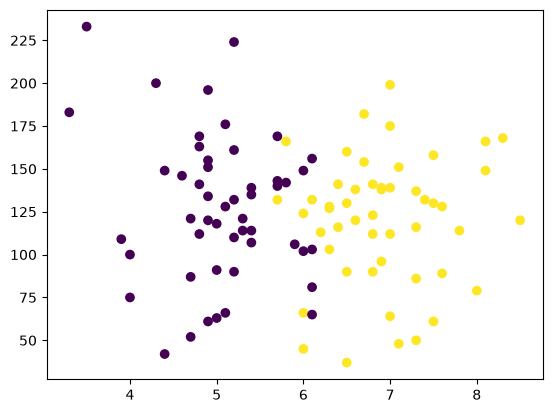

In [20]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [21]:
X=df.iloc[:,0:2]
y=df.iloc[:,-1]

In [22]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [23]:
y.shape

(100,)

In [24]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
44,7.5,61.0
23,4.7,87.0
77,7.3,50.0
26,7.0,199.0
29,7.0,112.0
...,...,...
13,6.4,116.0
50,3.5,233.0
8,6.1,156.0
99,6.2,113.0


In [26]:
y_train

44    1
23    0
77    1
26    1
29    1
     ..
13    1
50    0
8     0
99    1
24    0
Name: placement, Length: 90, dtype: int64

In [27]:
X_test

,cgpa,iq
30,7.6,128.0
85,5.8,166.0
62,6.0,102.0
47,5.2,161.0
63,6.3,128.0
9,5.1,66.0
61,7.3,137.0
71,6.1,132.0
91,7.5,158.0
97,6.7,182.0


In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

In [30]:
X_train = scaler.fit_transform(X_train)

In [31]:
X_train

array([[ 1.33852444, -1.51990921],
       [-1.07945519, -0.87419615],
       [ 1.16581161, -1.79309551],
       [ 0.90674236,  1.90733705],
       [ 0.90674236, -0.2533182 ],
       [ 0.82038595,  0.39239486],
       [ 0.12953462, -0.47683426],
       [-0.5613167 , -0.20364797],
       [-0.47496029, -0.20364797],
       [ 0.12953462, -1.42056874],
       [-0.47496029,  0.31788951],
       [-0.21589104,  1.16228352],
       [ 0.5613167 , -0.05463726],
       [ 0.73402953, -0.2533182 ],
       [-0.90674236, -1.51990921],
       [ 1.77030652, -1.07287709],
       [ 1.85666293,  1.08777816],
       [-0.73402953,  1.33612934],
       [ 0.82038595,  0.41722998],
       [ 1.59759369, -0.20364797],
       [ 1.33852444,  0.19371392],
       [ 0.04317821,  0.04470321],
       [-0.90674236,  0.81459187],
       [-0.99309878,  1.01327281],
       [ 1.42488086, -0.82452591],
       [-0.73402953,  0.14404368],
       [ 0.99309878, -1.84276574],
       [ 0.38860387,  0.46690022],
       [ 0.12953462,

In [32]:
X_test = scaler.transform(X_test)

In [33]:
X_test

array([[ 1.42488086,  0.14404368],
       [-0.12953462,  1.08777816],
       [ 0.04317821, -0.50166938],
       [-0.64767312,  0.96360257],
       [ 0.30224745,  0.14404368],
       [-0.73402953, -1.39573362],
       [ 1.16581161,  0.36755974],
       [ 0.12953462,  0.24338415],
       [ 1.33852444,  0.88909722],
       [ 0.64767312,  1.48514005]])

In [34]:
from sklearn.linear_model import LogisticRegression

In [35]:
clf = LogisticRegression()

In [36]:
# model training
clf.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [37]:
y_pred = clf.predict(X_test)

In [38]:
y_test

30    1
85    1
62    0
47    0
63    1
9     0
61    1
71    1
91    1
97    1
Name: placement, dtype: int64

In [39]:
from sklearn.metrics import accuracy_score

In [40]:
accuracy_score(y_test,y_pred)

0.8

In [41]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

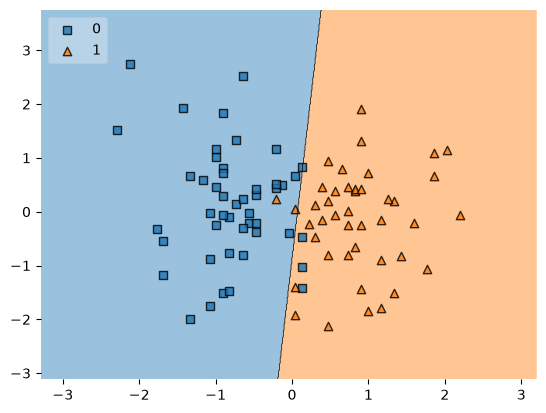

In [42]:
plot_decision_regions(X_train, y_train.values, clf=clf, legend=2)

In [43]:
import pickle

In [44]:
pickle.dump(clf,open('model.pkl','wb'))